# Sammenligning af to LLM'er: Haiko vs. Opus

Statistisk evaluering af to sprogmodeller på et eksamenssæt, hvor hvert spørgsmål er
bedømt af 5 evaluatorer. Metoderne (Jeffrey's interval og McNemars test) følger
`exercise7` fra kurset:

1. **Opsætning** – indlæs og ryd op i data (gøres én gang).
2. **Deskriptiv analyse** – accuracy pr. spørgsmålstype + agreement-matrix.
3. **Del 1 – Jeffrey's interval** – konfidensinterval for hver enkelt model.
4. **Del 2 – McNemars test** – statistisk sammenligning af de to modeller.


In [2]:
import numpy as np
import pandas as pd
import scipy.stats as st

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import binomtest

In [3]:

# Load data
pilot_path = "final pilot.csv"
df_pilot_study = pd.read_csv(pilot_path, sep=";", encoding="utf-8-sig", skiprows=2)

# Rename columns
df_pilot_study.columns = ['ID', 'Semester', 'Question', 'Haiku_True', 'Haiku_False', 'Opus_True', 'Opus_False']

# Fill NaN with 0
df_pilot_study = df_pilot_study.fillna(0)

df_pilot_study

,ID,Semester,Question,Haiku_True,Haiku_False,Opus_True,Opus_False
0,2,Fall 2025,B,0.0,1.0,1.0,0.0
1,3,Fall 2025,A,1.0,0.0,1.0,0.0
2,4,Fall 2025,D,1.0,0.0,1.0,0.0
3,5,Fall 2025,C,1.0,0.0,1.0,0.0
4,6,Fall 2025,B,0.0,1.0,0.0,1.0
5,7,Fall 2025,A,1.0,0.0,1.0,0.0
6,8,Fall 2025,C,1.0,0.0,1.0,0.0
7,9,Fall 2025,B,1.0,0.0,1.0,0.0
8,10,Fall 2025,D,1.0,0.0,0.0,1.0
9,11,Fall 2025,A,0.0,1.0,1.0,0.0


In [4]:


# Calculate accuracy (simply count True values)
haiku_correct = df_pilot_study['Haiku_True'].sum()
opus_correct = df_pilot_study['Opus_True'].sum()

accuracy_haiku = haiku_correct / 27
accuracy_opus = opus_correct / 27

print(f"Haiku: {int(haiku_correct)}/27 = {accuracy_haiku:.1%}")
print(f"Opus:  {int(opus_correct)}/27 = {accuracy_opus:.1%}")

Haiku: 16/27 = 59.3%
Opus:  23/27 = 85.2%


In [32]:
p1 = accuracy_haiku
p2 = accuracy_opus
alfa = 0.05
power = 0.80 

z_alfa_2 = st.norm.ppf(0.975)
z_beta = st.norm.ppf(0.80)

accuracy_difference = abs(p2-p1)
P_mean = (0.6296 + 0.7778) / 2

n = ((z_alfa_2 + z_beta)**2) * 2 * P_mean * (1-P_mean) / (accuracy_difference**2)
n

np.float64(48.69544299225633)

## 1. Opsætning

Her samles alle imports, og datafilen indlæses og renses **én gang**. Alle senere
celler genbruger `df` herfra i stedet for at indlæse filen forfra.


In [5]:
path = "Project_in_statistical_evaluation_of_AI_-DATA_CSV_1 (1).csv"

df = pd.read_csv(path, sep=";", encoding="utf-8-sig")


df

,Examset,Question,Q_Type,Haiko True,Haiko False,Opus True,Opus False,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,Spring 2025,1,Visual,5,0,5,0,NaN,NaN,NaN,NaN,NaN,NaN
1,Spring 2025,2,Visual,0,5,5,0,NaN,NaN,NaN,NaN,NaN,NaN
2,Spring 2025,3,Computational,0,5,5,0,NaN,NaN,NaN,NaN,NaN,NaN
3,Spring 2025,4,Visual,4,1,4,1,NaN,NaN,NaN,NaN,NaN,NaN
4,Spring 2025,5,Knowlegde,0,5,5,0,NaN,NaN,NaN,NaN,NaN,NaN
5,Spring 2025,6,Computational,1,4,5,0,NaN,NaN,NaN,NaN,NaN,NaN
6,Spring 2025,7,Computational,0,5,5,0,NaN,NaN,NaN,NaN,NaN,NaN
7,Spring 2025,8,Computational,0,5,5,0,NaN,NaN,NaN,NaN,NaN,NaN
8,Spring 2025,9,Visual,0,5,5,0,NaN,NaN,NaN,NaN,NaN,NaN
9,Spring 2025,10,Computational,0,5,1,4,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:


# Sti til datafilen (semikolon-separeret, BOM-tegn, og tomme "Unnamed"-kolonner til sidst)
path = "Project_in_statistical_evaluation_of_AI_-DATA_CSV_1 (1).csv"

df = pd.read_csv(path, sep=";", encoding="utf-8-sig")

# Ryd op:
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]   # fjern tomme kolonner
df.columns = df.columns.str.strip()                       # trim kolonnenavne
df["Q_Type"] = df["Q_Type"].str.strip().replace({"Knowlegde": "Knowledge"})  # ret stavefejl

df

,Examset,Question,Q_Type,Haiko True,Haiko False,Opus True,Opus False
0,Spring 2025,1,Visual,5,0,5,0
1,Spring 2025,2,Visual,0,5,5,0
2,Spring 2025,3,Computational,0,5,5,0
3,Spring 2025,4,Visual,4,1,4,1
4,Spring 2025,5,Knowledge,0,5,5,0
5,Spring 2025,6,Computational,1,4,5,0
6,Spring 2025,7,Computational,0,5,5,0
7,Spring 2025,8,Computational,0,5,5,0
8,Spring 2025,9,Visual,0,5,5,0
9,Spring 2025,10,Computational,0,5,1,4


Vi udvider data til **langt format** med 270 rækker (5 evaluatorer × 54 spørgsmål).
Hver evaluering bliver et binært udfald: `1` = korrekt, `0` = forkert. Disse variabler
(`y_true`, `yhatA`, `yhatB`) bruges i både Jeffrey's interval og McNemars test.


In [8]:


# Majority vote
majority_vote = []

for _, row in df.iterrows():
    haiko_vote = 1 if row['Haiko True'] > row['Haiko False'] else 0
    opus_vote = 1 if row['Opus True'] > row['Opus False'] else 0
    
    majority_vote.append({
        'Haiko': haiko_vote,
        'Opus': opus_vote
    })

df_majority = pd.DataFrame(majority_vote)

# Statistics
haiko_correct = df_majority['Haiko'].sum()
opus_correct = df_majority['Opus'].sum()

print(f"Haiko: {haiko_correct}/54 = {haiko_correct/54:.1%}")
print(f"Opus:  {opus_correct}/54 = {opus_correct/54:.1%}")



Haiko: 23/54 = 42.6%
Opus:  46/54 = 85.2%


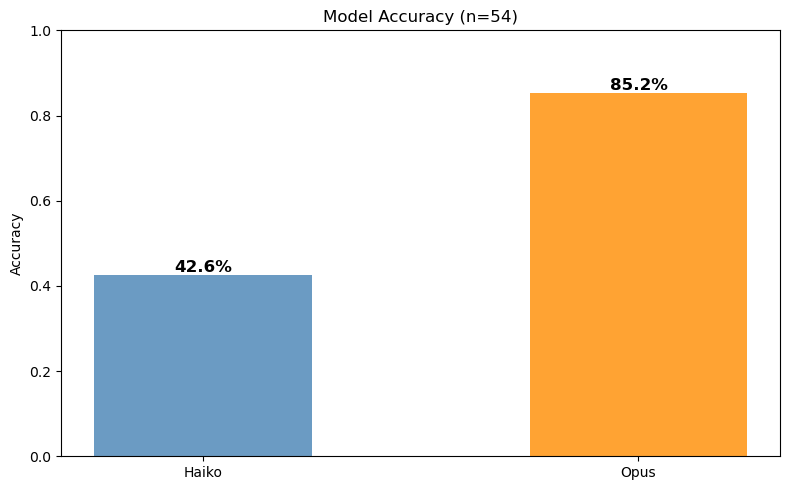

In [9]:
# Accuracy plot
fig, ax = plt.subplots(figsize=(8, 5))

haiko_acc = haiko_correct / 54
opus_acc = opus_correct / 54

bars = ax.bar(['Haiko', 'Opus'], [haiko_acc, opus_acc], 
              color=['steelblue', 'darkorange'], alpha=0.8, width=0.5)

ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy (n=54)')
ax.set_ylim([0, 1])

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1%}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

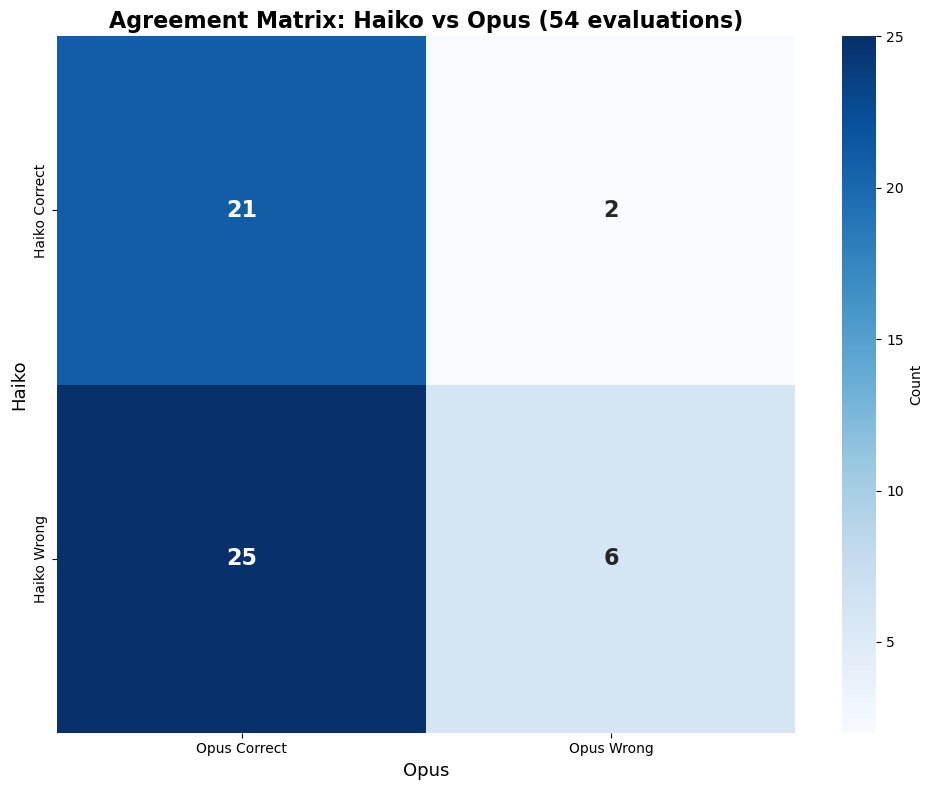

In [10]:
# [INSERT MAJORITY VOTE CODE HERE]

# ========== AGREEMENT MATRIX: HAIKO VS OPUS (54 observations) ==========

n11 = ((df_majority['Haiko'] == 1) & (df_majority['Opus'] == 1)).sum()
n12 = ((df_majority['Haiko'] == 1) & (df_majority['Opus'] == 0)).sum()
n21 = ((df_majority['Haiko'] == 0) & (df_majority['Opus'] == 1)).sum()
n22 = ((df_majority['Haiko'] == 0) & (df_majority['Opus'] == 0)).sum()

matrix = np.array([[n11, n12], [n21, n22]])

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Opus Correct', 'Opus Wrong'],
            yticklabels=['Haiko Correct', 'Haiko Wrong'],
            cbar_kws={'label': 'Count'}, 
            annot_kws={'size': 16, 'weight': 'bold'})

ax.set_title('Agreement Matrix: Haiko vs Opus (54 evaluations)', fontsize=16, fontweight='bold')
ax.set_xlabel('Opus', fontsize=13)
ax.set_ylabel('Haiko', fontsize=13)

plt.tight_layout()
plt.show()

In [11]:
def mcnemar(y_true, yhatA, yhatB, alpha=0.05):
    """Perform McNemar's test to compare the accuracy of two classifiers."""

    # Set up the contingency table
    nn = np.zeros((2, 2))
    cA = yhatA == y_true
    cB = yhatB == y_true
    nn[0, 0] = sum(cA & cB)
    nn[0, 1] = sum(cA & ~cB)
    nn[1, 0] = sum(~cA & cB)
    nn[1, 1] = sum(~cA & ~cB)

    n = len(y_true)
    n12 = nn[0, 1]
    n21 = nn[1, 0]

    E_theta = (n12 - n21) / n
    Q = n**2 * (n + 1) * (E_theta + 1) * (1 - E_theta) / (n * (n12 + n21) - (n12 - n21) ** 2)

    f = (E_theta + 1) / 2 * (Q - 1)
    g = (1 - E_theta) / 2 * (Q - 1)

    CI = tuple(bound * 2 - 1 for bound in st.beta.interval(1 - alpha, a=f, b=g))
    p = 2 * st.binom.cdf(min([n12, n21]), n=n12 + n21, p=0.5)

    return E_theta, CI, p

In [12]:
# Model A = Haiko, Model B = Opus. df_majority koder allerede korrekt(1)/forkert(0)
y_true = np.ones(len(df_majority), dtype=int)
yhatA  = df_majority['Haiko'].values
yhatB  = df_majority['Opus'].values

theta_hat, CI, p = mcnemar(y_true, yhatA, yhatB, alpha=0.05)

print("McNemars test  —  Haiko (A) vs Opus (B)")
print("-" * 40)
print(f"theta_hat (A-B) : {theta_hat:+.4f}")
print(f"95% CI          : [{CI[0]:.4f}, {CI[1]:.4f}]")
print(f"p-value         : {p:.3e}")
print("-" * 40)
print("Signifikant forskel" if p < 0.05 else "Ingen signifikant forskel", f"(alpha = 0.05)")

McNemars test  —  Haiko (A) vs Opus (B)
----------------------------------------
theta_hat (A-B) : -0.4259
95% CI          : [-0.5690, -0.2713]
p-value         : 5.648e-06
----------------------------------------
Signifikant forskel (alpha = 0.05)


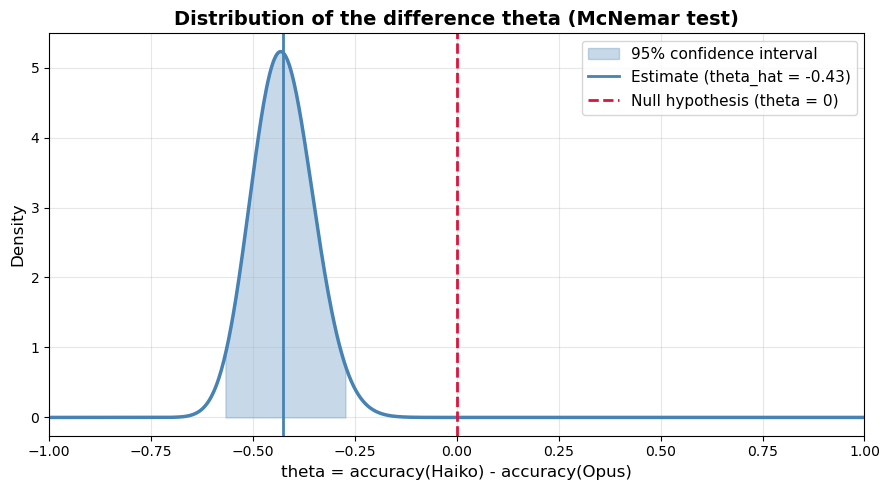

In [13]:
# Count how often the models disagree
n = len(y_true)
n12 = sum((yhatA == 1) & (yhatB == 0))   # Haiko correct, Opus wrong
n21 = sum((yhatA == 0) & (yhatB == 1))   # Haiko wrong, Opus correct

# Compute the parameters for the distribution (same formulas as in mcnemar)
E_theta = (n12 - n21) / n
Q = n**2 * (n + 1) * (E_theta + 1) * (1 - E_theta) / (n * (n12 + n21) - (n12 - n21)**2)
f = (E_theta + 1) / 2 * (Q - 1)
g = (1 - E_theta) / 2 * (Q - 1)

# Build the distribution of theta
theta = np.linspace(-1, 1, 1000)
density = 0.5 * st.beta.pdf((theta + 1) / 2, a=f, b=g)

# Draw the plot
plt.figure(figsize=(9, 5))
plt.plot(theta, density, color='steelblue', linewidth=2.5)          # the distribution

# Shade the 95% confidence interval
inside = (theta >= CI[0]) & (theta <= CI[1])
plt.fill_between(theta[inside], density[inside], color='steelblue', alpha=0.3,
                 label='95% confidence interval')

plt.axvline(theta_hat, color='steelblue', linewidth=2,
            label=f'Estimate (theta_hat = {theta_hat:.2f})')
plt.axvline(0, color='crimson', linestyle='--', linewidth=2,
            label='Null hypothesis (theta = 0)')

plt.xlabel('theta = accuracy(Haiko) - accuracy(Opus)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Distribution of the difference theta (McNemar test)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.margins(x=0)
plt.tight_layout()
plt.show()

mål med opgaven 


pilot study


hvorfor 5 gange på hver 


mcnemar forskel 

coxon test 


måske nogle sample size for proportion for de enekelte 



kommentarer om tendens for spørgsmålstyper

diskussion


konklussion